# CC3092 - Laboratorio 7 - Task 1

Este notebook implementa el pipeline solicitado para ETTh1: normalizacion de `OT`, split temporal 60/20/20, ventanas con $L=96$ y horizontes $H\in\{24,48\}$, ACF manual y baseline naive.

## Task 1.1 - Descarga y preprocesamiento

La normalizacion sigue literalmente el enunciado: primero se calculan $\mu$ y $\sigma$ sobre `OT` completa y luego se divide la serie normalizada en bloques temporales contiguos. No se mezclan ni se barajan observaciones.

In [1]:
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
DATA_PATH = Path("ETTh1.csv")

if not DATA_PATH.exists():
    urllib.request.urlretrieve(URL, DATA_PATH)

print(f"Dataset disponible en: {DATA_PATH.resolve()}")

Dataset disponible en: C:\Projects\Deep-Learning\app\ETTh1.csv


In [2]:
data = np.genfromtxt(DATA_PATH, delimiter=",", skip_header=1)
OT = data[:, -1].astype(np.float32)       # Variable objetivo: Oil Temperature
ALL = data[:, 1:].astype(np.float32)      # Las 7 variables numericas

# Desviacion estandar poblacional (ddof=0), consistente con np.std por defecto.
mu = OT.mean()
sigma = OT.std()
OT_norm = (OT - mu) / sigma

print(f"Filas: {len(OT):,}; variables: {ALL.shape[1]}")
print(f"mu={mu:.6f}, sigma={sigma:.6f}")
print(f"Media normalizada={OT_norm.mean():.6f}, std={OT_norm.std():.6f}")

Filas: 17,420; variables: 7
mu=13.324672, sigma=8.566700


Media normalizada=-0.000000, std=1.000000


In [3]:
# Split temporal contiguo: [train | validation | test].
N_total = len(OT_norm)
n_train = int(0.60 * N_total)
n_val = int(0.20 * N_total)

OT_train = torch.from_numpy(OT_norm[:n_train].copy())
OT_val = torch.from_numpy(OT_norm[n_train:n_train + n_val].copy())
OT_test = torch.from_numpy(OT_norm[n_train + n_val:].copy())

print("Tamanos:", len(OT_train), len(OT_val), len(OT_test))
print("Porcentajes reales:",
      f"{len(OT_train)/N_total:.2%}",
      f"{len(OT_val)/N_total:.2%}",
      f"{len(OT_test)/N_total:.2%}")

Tamanos: 10452 3484 3484
Porcentajes reales: 60.00% 20.00% 20.00%


### Construccion de ventanas

Para una ventana que inicia en el indice $i$, el ultimo elemento de entrada es $t=i+L-1$ y el objetivo es $t+H=i+L+H-1$. Por eso el numero de ejemplos es $N-L-H+1$.

In [4]:
def make_windows(series, L, H):
    """Construye X:(N,L) e y:(N,) para predecir x[t+H] desde L valores."""
    series = torch.as_tensor(series, dtype=torch.float32).flatten()
    n_examples = series.numel() - L - H + 1
    if L <= 0 or H <= 0:
        raise ValueError("L y H deben ser enteros positivos")
    if n_examples <= 0:
        raise ValueError("La serie es demasiado corta para L y H")

    # unfold genera todas las ventanas consecutivas; se conservan solo las
    # que tienen disponible el objetivo situado H pasos despues.
    X = series.unfold(dimension=0, size=L, step=1)[:n_examples].clone()
    start_y = L + H - 1
    y = series[start_y:start_y + n_examples].clone()
    return X, y

In [5]:
L = 96

X_tr_24, y_tr_24 = make_windows(OT_train, L=L, H=24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L=L, H=24)
X_ts_24, y_ts_24 = make_windows(OT_test,  L=L, H=24)

X_tr_48, y_tr_48 = make_windows(OT_train, L=L, H=48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L=L, H=48)
X_ts_48, y_ts_48 = make_windows(OT_test,  L=L, H=48)

for nombre, X, y in [
    ("train H=24", X_tr_24, y_tr_24),
    ("val   H=24", X_vl_24, y_vl_24),
    ("test  H=24", X_ts_24, y_ts_24),
    ("train H=48", X_tr_48, y_tr_48),
    ("val   H=48", X_vl_48, y_vl_48),
    ("test  H=48", X_ts_48, y_ts_48),
]:
    print(f"{nombre}: X={tuple(X.shape)}, y={tuple(y.shape)}")

train H=24: X=(10333, 96), y=(10333,)
val   H=24: X=(3365, 96), y=(3365,)
test  H=24: X=(3365, 96), y=(3365,)
train H=48: X=(10309, 96), y=(10309,)
val   H=48: X=(3341, 96), y=(3341,)
test  H=48: X=(3341, 96), y=(3341,)


## Task 1.2 - ACF manual

La implementacion usa exactamente los factores $1/(N-k)$ en el numerador y $1/N$ en el denominador indicados en el documento. Se convierte temporalmente a `float64` para reducir error numerico.

In [6]:
def acf_manual(series, max_lag):
    """ACF para lags 0..max_lag, sin usar funciones estadisticas de alto nivel."""
    x = np.asarray(series, dtype=np.float64).reshape(-1)
    N = x.size
    if not 0 <= max_lag < N:
        raise ValueError("max_lag debe estar entre 0 y N-1")

    x_bar = x.mean()
    centered = x - x_bar
    denominator = np.sum(centered ** 2) / N
    if denominator == 0:
        raise ValueError("La ACF no esta definida para una serie constante")

    rho = np.empty(max_lag + 1, dtype=np.float64)
    for k in range(max_lag + 1):
        numerator = np.sum(centered[k:] * centered[:N-k]) / (N - k)
        rho[k] = numerator / denominator
    return rho

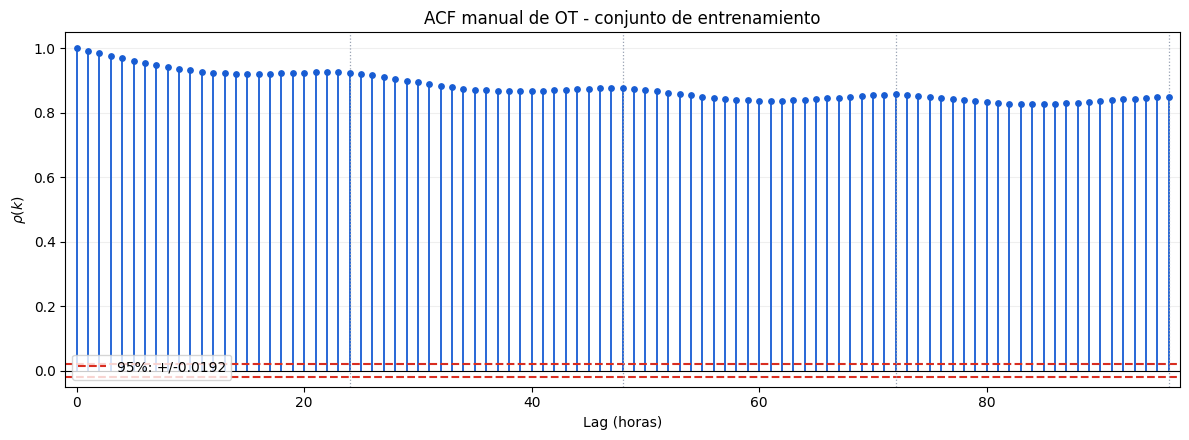

IC 95%: +/-0.019172
ACF( 0) = 1.000000
ACF(24) = 0.924957
ACF(48) = 0.876343
ACF(72) = 0.857162
ACF(96) = 0.848853


In [7]:
max_lag = 96
acf_values = acf_manual(OT_train.numpy(), max_lag=max_lag)
lags = np.arange(max_lag + 1)
confidence = 1.96 / np.sqrt(len(OT_train))

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.vlines(lags, 0, acf_values, color="#175CD3", linewidth=1.3)
ax.scatter(lags, acf_values, color="#175CD3", s=15, zorder=3)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(confidence, color="#D92D20", linestyle="--",
           label=f"95%: +/-{confidence:.4f}")
ax.axhline(-confidence, color="#D92D20", linestyle="--")
for daily_lag in (24, 48, 72, 96):
    ax.axvline(daily_lag, color="#98A2B3", linestyle=":", linewidth=0.9)
ax.set(title="ACF manual de OT - conjunto de entrenamiento",
       xlabel="Lag (horas)", ylabel=r"$\rho(k)$", xlim=(-1, 97))
ax.grid(axis="y", alpha=0.2)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"IC 95%: +/-{confidence:.6f}")
for k in (0, 24, 48, 72, 96):
    print(f"ACF({k:>2}) = {acf_values[k]:.6f}")

In [8]:
# Un pico local debe ser mayor o igual que sus dos vecinos.
local_peaks = [k for k in range(1, max_lag)
               if acf_values[k] >= acf_values[k-1]
               and acf_values[k] >= acf_values[k+1]]

print("Picos locales (lag, ACF):")
for k in local_peaks:
    print(f"  ({k}, {acf_values[k]:.6f})")

Picos locales (lag, ACF):
  (22, 0.926165)
  (47, 0.876957)
  (72, 0.857162)


### Interpretacion

- Despues del pico trivial de lag 0, el primer pico local relevante esta en **lag 22**, con $\rho(22)\approx0.9262$. La zona 22-24 horas es casi plana y $\rho(24)\approx0.9250$, por lo que el resultado representa una periodicidad diaria aproximada de la temperatura del aceite. La ligera diferencia entre 22 y 24 horas puede deberse a variaciones operativas y a que el ciclo termico no es perfectamente sinusoidal.
- Tambien aparecen picos locales cerca de 47 y 72 horas, con ACF aproximadas de 0.8770 y 0.8572. Son multiplos aproximados del ciclo diario.
- **$L=96$ es una eleccion apropiada:** contiene cuatro dias completos y, por tanto, varios ciclos diarios que el modelo puede comparar. Ademas, la dependencia sigue siendo fuerte en los lags 24, 48, 72 y 96: aproximadamente 0.9250, 0.8763, 0.8572 y 0.8489. Una ventana claramente menor que 48 perderia varios ciclos utiles. Como $\rho(96)$ aun es alto, una ventana mayor podria evaluarse, pero con una ACF calculada solo hasta 96 no hay evidencia suficiente para escoger cuanto mayor; 96 es un compromiso razonable entre contexto y costo computacional.

## Baseline naive

El baseline predice que el valor futuro sera igual al ultimo valor observado de cada ventana. Es una referencia exigente cuando la serie presenta alta persistencia.

In [9]:
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
naive_mae_48 = torch.abs(y_vl_48 - X_vl_48[:, -1]).mean().item()
print(f"Naive MAE H=24: {naive_mae:.6f}")
print(f"Naive MAE H=48: {naive_mae_48:.6f}")

Naive MAE H=24: 0.199629
Naive MAE H=48: 0.260401


## Verificacion oficial del Task 1

In [10]:
_ok = True
# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], \
    "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"
print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)


## Registro de uso limitado de IA generativa

**Prompt utilizado:** "ayudame a hacer el task 1 como lo hariamos? con las instrucciones del doc"

**Por que funciono:** el prompt delimito el trabajo al Task 1 y exigio seguir el documento. La respuesta se contrasto con la formula de ventanas, la formula manual de la ACF y la celda de verificacion proporcionadas por el curso. El codigo se comprobo ejecutando todas las celdas en orden.